In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#importing packages and classes
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import VQC #loading qisket quantum ML classes
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import dill
import os
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt  
import pickle


In [3]:
#loading and displaying power theft dataset
dataset = pd.read_csv("Dataset/PowerTheft.csv")
dataset

,UserId,IsStealer,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,...,10/22/2016,10/23/2016,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016
0,000395F84A94D4CB2E5D4D77372CFB4D,1,22.23,22.46,20.13,21.79,24.00,24.00,19.10,15.91,...,24.20,18.89,3.96,19.54,19.32,37.87,26.44,9.49,14.28,22.83
1,001D7B28FA434B82E6F3325137E32C60,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3.96,4.85,3.37,3.13,4.54,2.89,3.38,3.33,3.38,3.36
2,002287278ED4108B03469932AD4EE6A3,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.85,1.02,0.90,1.56,1.51,1.11,1.85,1.05,0.90,1.61
3,003064374E9E69D1D9DB06B8B7A6F550,1,0.66,0.69,0.75,3.99,3.61,0.81,4.71,1.45,...,5.68,2.15,5.83,8.02,5.61,6.34,8.78,11.07,15.22,7.53
4,0042EF8D355027B740081F5C919C1B7A,1,0.10,131.91,172.79,118.57,119.59,174.67,97.79,133.38,...,130.98,200.51,213.12,175.59,195.17,185.72,85.10,111.93,207.11,234.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,063B4F79CF8326FA47839D32DCAE9B22,0,15.10,10.83,10.65,11.38,13.51,11.45,10.53,11.04,...,19.05,20.20,20.81,16.23,18.77,17.26,17.85,15.17,17.98,17.96
1796,063C333CDD96656C4E33BD09718A76F2,0,9.53,11.74,10.16,12.14,15.64,11.51,11.19,9.08,...,0.01,0.01,0.00,0.00,0.00,0.00,0.91,0.73,1.26,1.32
1797,063D586AA5D98763C6052176F5544A94,0,7.39,7.76,7.09,6.62,6.79,8.47,10.01,6.74,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1798,063EB149043744D4404A30AE8AF3F89D,0,5.14,4.43,5.09,4.19,4.18,4.27,3.51,3.20,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


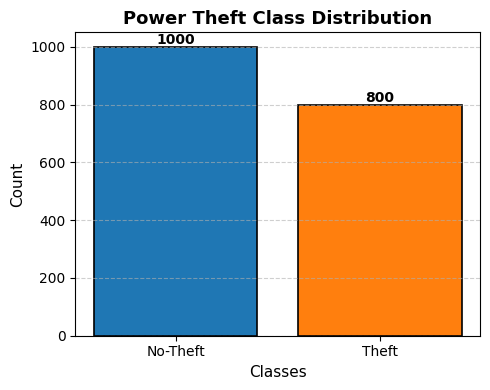

In [4]:
labels, count = np.unique(dataset['IsStealer'], return_counts=True)
labels = ['No-Theft', 'Theft']
plt.figure(figsize=(5, 4))
bars = plt.bar(labels, count, color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.2)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', fontsize=10, 
             fontweight='bold')
plt.title("Power Theft Class Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Classes", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [5]:
#dataset processing such as extracting X and Y training features and then shuffling and normalizing features
Y = dataset['IsStealer'] #get theft target values
dataset.drop(['UserId','IsStealer'], axis = 1,inplace=True)#drop irrelevant features
X = dataset.values
num_qubits = 4
pca = PCA(n_components=num_qubits)
X = pca.fit_transform(X)#reduce dimension
scaler = StandardScaler()
X = scaler.fit_transform(X)#normalize features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffly features
X = X[indices]
Y = Y[indices]
X = X[0:500]
Y = Y[0:500]
print("Normalized Features = "+str(X))

Normalized Features = [[-0.02488679  0.02530829 -0.05052287 -0.06281275]
 [-0.03110875  0.06299329  0.23564094  0.01165505]
 [-0.02917891  0.05105144  0.14279438 -0.03246754]
 ...
 [-0.03139202  0.06618451  0.24321998  0.00192145]
 [-0.02870895  0.03287663  0.21275234  0.06702774]
 [-0.02880424  0.03711089  0.19452593  0.09795322]]


In [6]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
f = open('model/data.pckl', 'rb')
data = pickle.load(f)
f.close()
X_train, X_test, y_train, y_test  = data
print("Dataset Train & Test Split Completed")

Dataset Train & Test Split Completed


In [7]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [8]:
#function to calculate accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    

In [9]:
#training XGBOOST on 80% training data and then evaluate performnace using 20% test data
xg_cls = XGBClassifier(n_estimators=10)
xg_cls.fit(X_train, y_train)
#perform prediction on test data
predict = xg_cls.predict(X_test)
#call function to calculate accuracy and other metrics
calculateMetrics("XGBoost", predict, y_test)

XGBoost Accuracy  :  86.0
XGBoost Precision : 88.57142857142857
XGBoost Recall    : 85.22681653954236
XGBoost FScore    : 85.53121124431583


In [10]:
#training XGBOOST on 80% training data and then evaluate performnace using 20% test data
lgbm_cls = LGBMClassifier(n_estimators=5)
lgbm_cls.fit(X_train, y_train)
#perform prediction on test data
predict = lgbm_cls.predict(X_test)
#call function to calculate accuracy and other metrics
calculateMetrics("LightGBM", predict, y_test)

[LightGBM] [Info] Number of positive: 188, number of negative: 222
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 549
[LightGBM] [Info] Number of data points in the train set: 410, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458537 -> initscore=-0.166235
[LightGBM] [Info] Start training from score -0.166235
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Accuracy  :  73.0
LightGBM Precision : 74.04513888888889
LightGBM 

In [11]:
#training propose Fully Hybrid QVC-DRC quantum ML classifier usinbg training features
# Create quantum feature map and kernel
feature_map = ZZFeatureMap(feature_dimension=X.shape[1], reps=2)
#create DRC object
drc = Sampler()
#combining VQC with drc as fully hybrid model
fh_qvc = VQC(sampler=drc, feature_map=feature_map)
#train qvc model
if os.path.exists("model/propose.pckl") == False:
    fh_qvc.fit(X_train, y_train)
else:
    with open('model/propose.pckl', 'rb') as f:
        fh_qvc = dill.load(f)
    f.close()
# prediction on test data
predict = fh_qvc.predict(X_test)
#call function to calculate accuracy and other metrics
calculateMetrics("Propose FH-QVC-DRC Model", predict, y_test)

Propose FH-QVC-DRC Model Accuracy  :  88.0
Propose FH-QVC-DRC Model Precision : 89.23917612442203
Propose FH-QVC-DRC Model Recall    : 87.47490967482938
Propose FH-QVC-DRC Model FScore    : 87.76009791921663


In [12]:
#creating extension fully hybrid QVC DRC model by utilizing entanglement features which will secured quantum model and make execution
#faster along with features optimization which will help algorothm in gaining accuracy
#creating features using entanglement
entanglement_feature_map = ZZFeatureMap(feature_dimension=X.shape[1], reps=2, entanglement='full', parameter_prefix='x')
drc = Sampler()
#combining VQC with drc as fully hybrid model
extension_model = VQC(sampler=drc, feature_map=entanglement_feature_map)
#train qvc model
if os.path.exists("model/extension.pckl") == False:
    extension_model.fit(X_train, y_train)
else:
    with open('model/extension.pckl', 'rb') as f:
        extension_model = dill.load(f)
    f.close()
# prediction on test data
predict = extension_model.predict(X_test)
#call function to calculate accuracy and other metrics
calculateMetrics("Extension FH-QVC-DRC Entanglement", predict, y_test)

Extension FH-QVC-DRC Entanglement Accuracy  :  91.0
Extension FH-QVC-DRC Entanglement Precision : 91.58456486042692
Extension FH-QVC-DRC Entanglement Recall    : 90.66639903653152
Extension FH-QVC-DRC Entanglement FScore    : 90.88976617066504


In [13]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Existing XGBoost','Accuracy',accuracy[0]],['Existing XGBoost','Precision',precision[0]],['Existing XGBoost','Recall',recall[0]],['Existing XGBoost','FSCORE',fscore[0]],
                   ['Existing LightGBM','Accuracy',accuracy[1]],['Existing LightGBM','Precision',precision[1]],['Existing LightGBM','Recall',recall[1]],['Existing LightGBM','FSCORE',fscore[1]],
                   ['Propose FH-QVC-DRC','Accuracy',accuracy[2]],['Propose FH-QVC-DRC','Precision',precision[2]],['Propose FH-QVC-DRC','Recall',recall[2]],['Propose FH-QVC-DRC','FSCORE',fscore[2]],
                   ['Extension FH-QVC-DRC-ENT','Accuracy',accuracy[3]],['Extension FH-QVC-DRC-ENT','Precision',precision[3]],['Extension FH-QVC-DRC-ENT','Recall',recall[3]],['Extension FH-QVC-DRC-ENT','FSCORE',fscore[3]],
                  ],columns=['Parameters','Algorithms','Value'])

In [14]:
#display all algorithm performnace
algorithms = ['Existing XGBoost', 'Existing LightGBM','Propose FH-QVC-DRC','Extension FH-QVC-DRC-ENT']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data    

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Existing XGBoost,86.0,88.571429,85.226817,85.531211
1,Existing LightGBM,73.0,74.045139,72.240064,72.196478
2,Propose FH-QVC-DRC,88.0,89.239176,87.474910,87.760098
3,Extension FH-QVC-DRC-ENT,91.0,91.584565,90.666399,90.889766


In [15]:
pickle.dump(pca, open("model/pca.pkl", "wb"))
pickle.dump(scaler, open("model/scaler.pkl", "wb"))

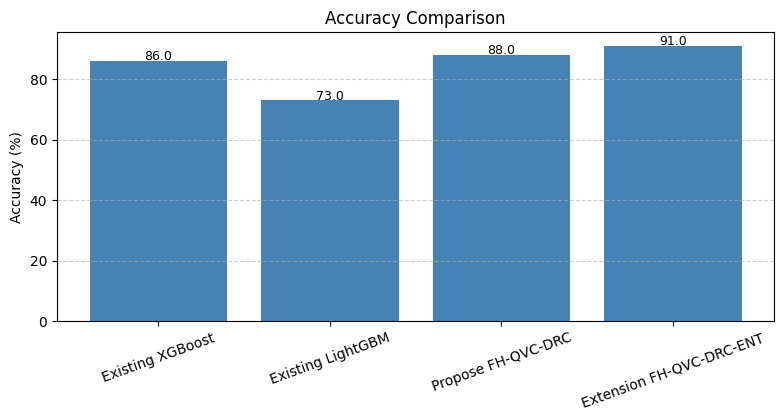

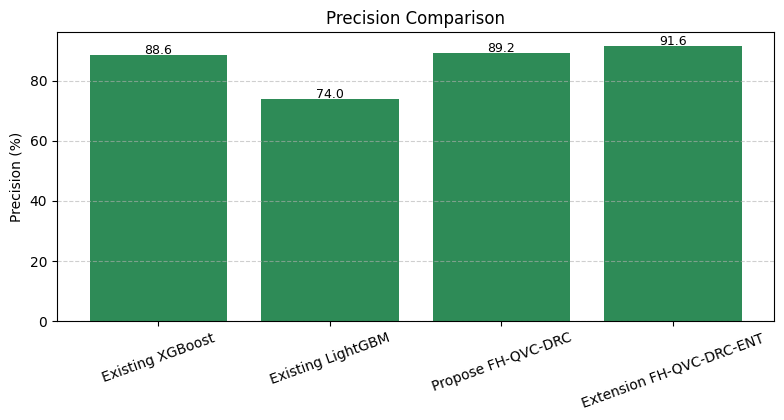

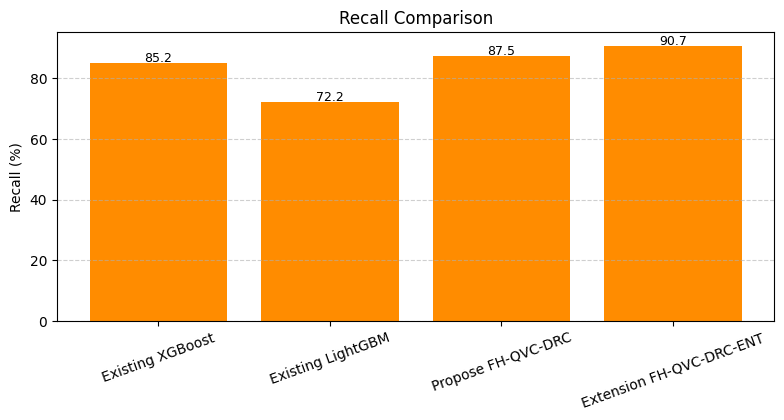

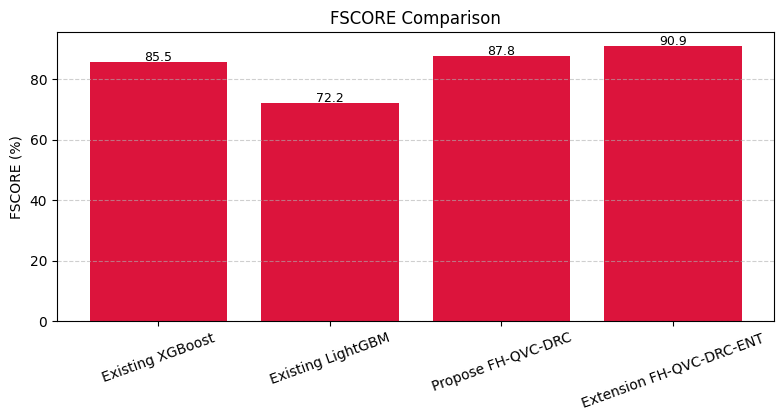

In [16]:
metrics = ['Accuracy', 'Precision', 'Recall', 'FSCORE']
colors = ['steelblue', 'seagreen', 'darkorange', 'crimson']

for m,c in zip(metrics, colors):
    plt.figure(figsize=(8,4.3))
    plt.bar(data['Algorithm Name'], data[m], color=c)
    for i,v in enumerate(data[m]): plt.text(i, v+0.3, f"{v:.1f}", ha='center', fontsize=9)
    plt.title(f'{m} Comparison')
    plt.ylabel(f'{m} (%)')
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
